Imports:

In [2]:
import numpy as np
from pathlib import Path
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

Cultivator Dictionary:

In [3]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

read_spectrum function:

In [4]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

Load all spectra:

In [5]:
all_data = {}

for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        print(f"Not found: {folder_name}")
        continue
    files = list(folder_path.rglob("*.txt"))
    spectra = []
    for f in files:
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            spectra.append((rs, intens))
    all_data[folder_name] = spectra
    print(f"{meta['label']}: {len(spectra)} spectra loaded")

AAC Chrome: 324 spectra loaded
AAC Lacombe: 324 spectra loaded
AAC Liscard: 324 spectra loaded
CDC Amarillo: 324 spectra loaded
CDC Athabasca: 324 spectra loaded
CDC Canary: 324 spectra loaded
CDC Dakota: 324 spectra loaded
CDC Golden: 324 spectra loaded
CDC Greenwater: 324 spectra loaded
CDC Inca: 324 spectra loaded
CDC Jasper: 324 spectra loaded
CDC Lewochko: 324 spectra loaded
CDC Meadow: 324 spectra loaded
CDC Patrick: 324 spectra loaded
CDC Saffron: 324 spectra loaded
CDC Spectrum: 324 spectra loaded
CDC Spruce: 324 spectra loaded
CDC Striker: 324 spectra loaded
CDC Tetris: 324 spectra loaded
Redbat 88: 324 spectra loaded


Preprocessing functions:

In [6]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc(X):
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Preprocessing combinations: {len(preprocessing_combos)}")

Preprocessing combinations: 8


X and y:

In [7]:
X = []
y = []

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for rs, intens in spectra:
        X.append(intens)
        y.append(meta['cys'])

X = np.array(X)
y = np.array(y)

cultivar_names = list(CULTIVARS.keys())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6480, 1530)
y shape: (6480,)


SVR Hyperparameter Optimisation:

In [11]:
from sklearn.model_selection import cross_val_score

# Apply best preprocessing
X_pre = snv(savitzky_golay_smooth(X))

# Scale for SVR
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pre)

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Grid search over key hyperparameters
param_grid = {
    'C':       [0.1, 1, 10, 100],
    'epsilon': [0.001, 0.01, 0.1],
    'gamma':   ['scale', 'auto']
}

svr = SVR(kernel='rbf')
grid_search = GridSearchCV(
    svr, param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1   
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score  = np.sqrt(-grid_search.best_score_)

print(f"\nBest parameters: {best_params}")
print(f"Best CV RMSE:    {best_score:.5f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'C': 100, 'epsilon': 0.001, 'gamma': 'auto'}
Best CV RMSE:    0.00557


In [12]:
results_svr = []

for combo_name, preprocess_fn in preprocessing_combos.items():
    print(f"\nTesting: {combo_name}")

    try:
        X_combo = preprocess_fn(X)
    except Exception as e:
        print(f" Failed: {e}")
        continue

    # Scale for SVR
    scaler_combo = StandardScaler()
    X_combo_scaled = scaler_combo.fit_transform(X_combo)

    # 80/20 split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_combo_scaled, y, test_size=0.2, random_state=42
    )

    # Train SVR with best parameters
    svr_combo = SVR(kernel='rbf',
                    C=best_params['C'],
                    epsilon=best_params['epsilon'],
                    gamma=best_params['gamma'])
    svr_combo.fit(X_tr, y_tr)
    y_pred_te = svr_combo.predict(X_te)

    rmse_8020 = np.sqrt(mean_squared_error(y_te, y_pred_te))
    r2_8020   = r2_score(y_te, y_pred_te)
    rpd_8020  = y_te.std() / rmse_8020

    print(f"  80/20 → RMSE: {rmse_8020:.4f}  R²: {r2_8020:.4f}  RPD: {rpd_8020:.4f}")

    # LOCOCV
    all_true, all_pred = [], []

    for held_out in cultivar_names:
        X_tr_l, y_tr_l = [], []
        X_te_l, y_te_l = [], []

        for folder_name, meta in CULTIVARS.items():
            spectra = all_data.get(folder_name, [])
            for rs, intens in spectra:
                arr     = np.array([intens])
                arr_pre = preprocess_fn(arr)[0]
                if folder_name == held_out:
                    X_te_l.append(arr_pre)
                    y_te_l.append(meta['cys'])
                else:
                    X_tr_l.append(arr_pre)
                    y_tr_l.append(meta['cys'])

        X_tr_l = np.array(X_tr_l)
        X_te_l = np.array(X_te_l)

        # Scale within each fold
        scaler_fold = StandardScaler()
        X_tr_l = scaler_fold.fit_transform(X_tr_l)
        X_te_l = scaler_fold.transform(X_te_l)

        svr_loco = SVR(kernel='rbf',
                       C=best_params['C'],
                       epsilon=best_params['epsilon'],
                       gamma=best_params['gamma'])
        svr_loco.fit(X_tr_l, np.array(y_tr_l))
        y_pred_l = svr_loco.predict(X_te_l)

        all_true.extend(y_te_l)
        all_pred.extend(y_pred_l)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse_loco = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_loco   = r2_score(all_true, all_pred)
    rpd_loco  = all_true.std() / rmse_loco

    print(f"  LOCO  → RMSE: {rmse_loco:.4f}  R²: {r2_loco:.4f}  RPD: {rpd_loco:.4f}")

    results_svr.append({
        "Preprocessing": combo_name,
        "RMSE_8020":     rmse_8020,
        "R2_8020":       r2_8020,
        "RPD_8020":      rpd_8020,
        "RMSE_LOCO":     rmse_loco,
        "R2_LOCO":       r2_loco,
        "RPD_LOCO":      rpd_loco,
    })

print("\n All SVR combinations done!")


Testing: SG + SNV
  80/20 → RMSE: 0.0053  R²: 0.8935  RPD: 3.0644
  LOCO  → RMSE: 0.0200  R²: -0.4750  RPD: 0.8234

Testing: SG + MSC
  80/20 → RMSE: 0.0057  R²: 0.8783  RPD: 2.8660
  LOCO  → RMSE: 0.0248  R²: -1.2826  RPD: 0.6619

Testing: SG + 1st Deriv
  80/20 → RMSE: 0.0082  R²: 0.7490  RPD: 1.9960
  LOCO  → RMSE: 0.0197  R²: -0.4364  RPD: 0.8344

Testing: SG + 2nd Deriv
  80/20 → RMSE: 0.0095  R²: 0.6667  RPD: 1.7320
  LOCO  → RMSE: 0.0196  R²: -0.4191  RPD: 0.8395

Testing: SG + SNV + 1st Der
  80/20 → RMSE: 0.0090  R²: 0.6996  RPD: 1.8246
  LOCO  → RMSE: 0.0197  R²: -0.4314  RPD: 0.8358

Testing: SG + SNV + 2nd Der
  80/20 → RMSE: 0.0101  R²: 0.6216  RPD: 1.6256
  LOCO  → RMSE: 0.0199  R²: -0.4579  RPD: 0.8282

Testing: SG + MSC + 1st Der
  80/20 → RMSE: 0.0089  R²: 0.7064  RPD: 1.8455
  LOCO  → RMSE: 0.0197  R²: -0.4364  RPD: 0.8344

Testing: SG + MSC + 2nd Der
  80/20 → RMSE: 0.0100  R²: 0.6270  RPD: 1.6374
  LOCO  → RMSE: 0.0196  R²: -0.4191  RPD: 0.8395

 All SVR combinatio

Results table and plot:

              SVR PREPROCESSING COMPARISON RESULTS
Preprocessing           RMSE_8020  R2_8020  RPD_8020  RMSE_LOCO   R2_LOCO  RPD_LOCO
-------------------------------------------------------------------------------------
SG + SNV                   0.0053   0.8935    3.0644     0.0200   -0.4750    0.8234
SG + MSC                   0.0057   0.8783    2.8660     0.0248   -1.2826    0.6619
SG + 1st Deriv             0.0082   0.7490    1.9960     0.0197   -0.4364    0.8344
SG + 2nd Deriv             0.0095   0.6667    1.7320     0.0196   -0.4191    0.8395
SG + SNV + 1st Der         0.0090   0.6996    1.8246     0.0197   -0.4314    0.8358
SG + SNV + 2nd Der         0.0101   0.6216    1.6256     0.0199   -0.4579    0.8282
SG + MSC + 1st Der         0.0089   0.7064    1.8455     0.0197   -0.4364    0.8344
SG + MSC + 2nd Der         0.0100   0.6270    1.6374     0.0196   -0.4191    0.8395

Best 80/20 preprocessing: SG + SNV
Best LOCO  preprocessing: SG + MSC + 2nd Der


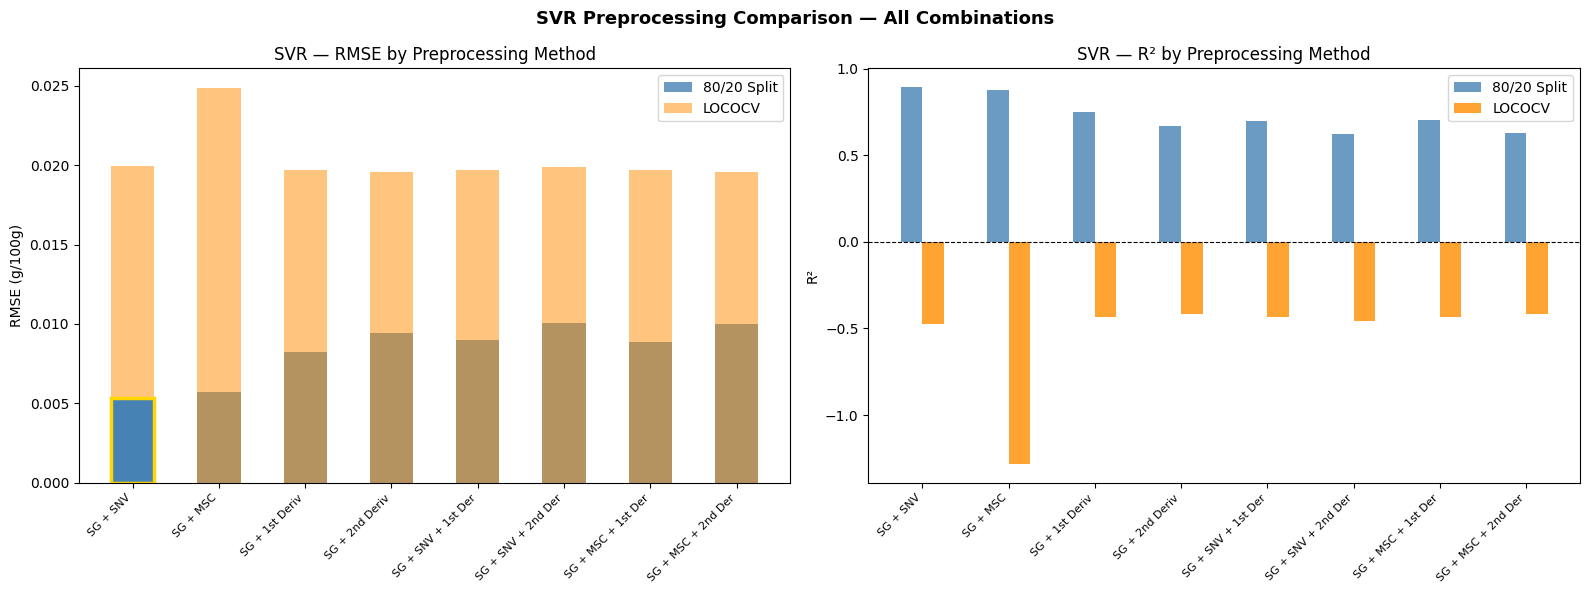

In [13]:
import pandas as pd

df_svr = pd.DataFrame(results_svr)

print("="*85)
print("              SVR PREPROCESSING COMPARISON RESULTS")
print("="*85)
print(f"{'Preprocessing':<22} {'RMSE_8020':>10} {'R2_8020':>8} {'RPD_8020':>9} {'RMSE_LOCO':>10} {'R2_LOCO':>9} {'RPD_LOCO':>9}")
print("-"*85)
for _, row in df_svr.iterrows():
    print(f"{row['Preprocessing']:<22} "
          f"{row['RMSE_8020']:>10.4f} {row['R2_8020']:>8.4f} {row['RPD_8020']:>9.4f} "
          f"{row['RMSE_LOCO']:>10.4f} {row['R2_LOCO']:>9.4f} {row['RPD_LOCO']:>9.4f}")
print("="*85)

best_8020 = df_svr.loc[df_svr['RMSE_8020'].idxmin(), 'Preprocessing']
best_loco  = df_svr.loc[df_svr['RMSE_LOCO'].idxmin(), 'Preprocessing']
print(f"\nBest 80/20 preprocessing: {best_8020}")
print(f"Best LOCO  preprocessing: {best_loco}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = df_svr['Preprocessing'].tolist()
x = np.arange(len(labels))
width = 0.5

ax1 = axes[0]
ax1.bar(x, df_svr['RMSE_8020'], width,
        color='steelblue', alpha=0.8, label='80/20 Split')
ax1.bar(x, df_svr['RMSE_LOCO'], width,
        color='darkorange', alpha=0.5, label='LOCOCV')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel("RMSE (g/100g)")
ax1.set_title("SVR — RMSE by Preprocessing Method")
ax1.legend()
# Highlight best 80/20
ax1.bar(df_svr['RMSE_8020'].idxmin(), df_svr['RMSE_8020'].min(),
        width, color='steelblue', alpha=1.0,
        edgecolor='gold', linewidth=2.5)

ax2 = axes[1]
ax2.bar(x - width/4, df_svr['R2_8020'], width/2,
        color='steelblue', alpha=0.8, label='80/20 Split')
ax2.bar(x + width/4, df_svr['R2_LOCO'], width/2,
        color='darkorange', alpha=0.8, label='LOCOCV')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel("R²")
ax2.set_title("SVR — R² by Preprocessing Method")
ax2.legend()

plt.suptitle("SVR Preprocessing Comparison — All Combinations",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("SVR_preprocessing_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

Final SVR Results Plot:

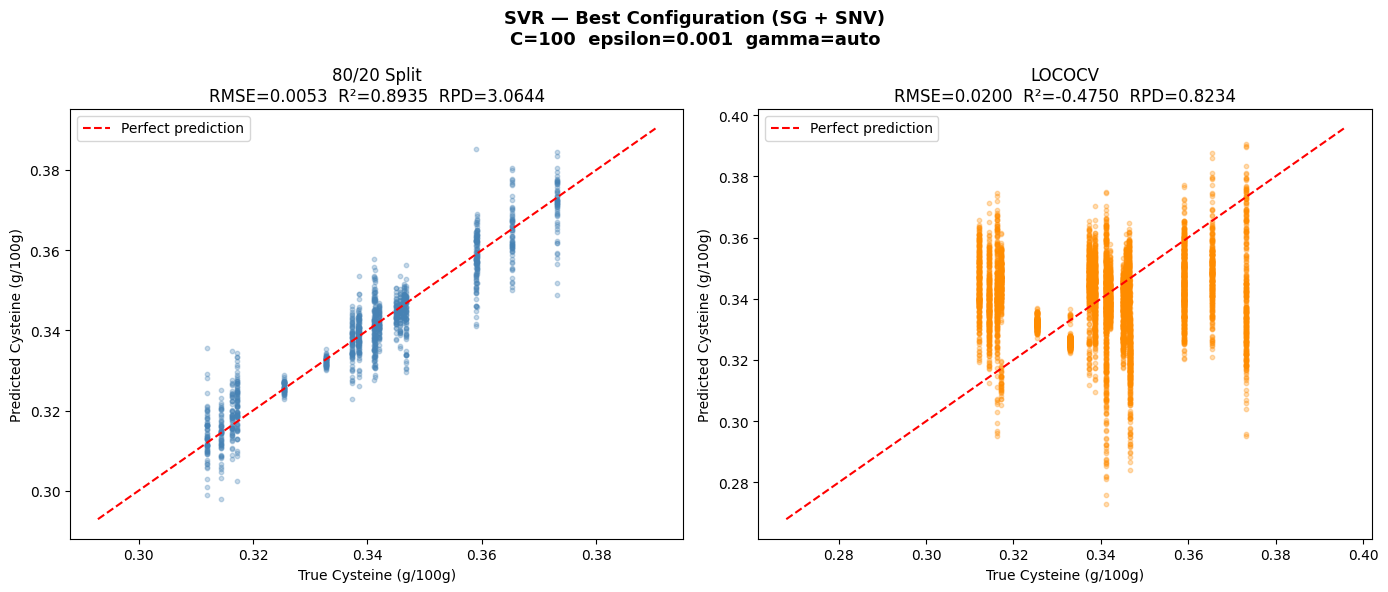


         SVR FINAL RESULTS SUMMARY
Metric                   80/20 Split          LOCOCV
-------------------------------------------------------
RMSE                          0.0053          0.0200
R²                            0.8935         -0.4750
RPD                           3.0644          0.8234
Preprocessing               SG + SNV        SG + SNV
C                                100             100
Epsilon                        0.001           0.001
Gamma                           auto            auto


In [14]:
# Best preprocessing is SG + SNV
X_best = snv(savitzky_golay_smooth(X))

scaler_best = StandardScaler()
X_best_scaled = scaler_best.fit_transform(X_best)

# ── 80/20 Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X_best_scaled, y, test_size=0.2, random_state=42
)

svr_best = SVR(kernel='rbf',
               C=best_params['C'],
               epsilon=best_params['epsilon'],
               gamma=best_params['gamma'])
svr_best.fit(X_train, y_train)

y_pred_train = svr_best.predict(X_train)
y_pred_test  = svr_best.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)
rpd_test   = y_test.std() / rmse_test

# ── LOCOCV ──
all_y_true_svr = []
all_y_pred_svr = []

for held_out in cultivar_names:
    X_tr_l, y_tr_l = [], []
    X_te_l, y_te_l = [], []

    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        for rs, intens in spectra:
            arr     = np.array([intens])
            arr_pre = snv(savitzky_golay_smooth(arr))[0]
            if folder_name == held_out:
                X_te_l.append(arr_pre)
                y_te_l.append(meta['cys'])
            else:
                X_tr_l.append(arr_pre)
                y_tr_l.append(meta['cys'])

    X_tr_l = np.array(X_tr_l)
    X_te_l = np.array(X_te_l)

    scaler_fold = StandardScaler()
    X_tr_l = scaler_fold.fit_transform(X_tr_l)
    X_te_l = scaler_fold.transform(X_te_l)

    svr_fold = SVR(kernel='rbf',
                   C=best_params['C'],
                   epsilon=best_params['epsilon'],
                   gamma=best_params['gamma'])
    svr_fold.fit(X_tr_l, np.array(y_tr_l))
    y_pred_l = svr_fold.predict(X_te_l)

    all_y_true_svr.extend(y_te_l)
    all_y_pred_svr.extend(y_pred_l)

all_y_true_svr = np.array(all_y_true_svr)
all_y_pred_svr = np.array(all_y_pred_svr)

rmse_loco = np.sqrt(mean_squared_error(all_y_true_svr, all_y_pred_svr))
r2_loco   = r2_score(all_y_true_svr, all_y_pred_svr)
rpd_loco  = all_y_true_svr.std() / rmse_loco

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.scatter(y_test, y_pred_test, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test.min(), y_pred_test.min()) - 0.005
max_val = max(y_test.max(), y_pred_test.max()) + 0.005
ax1.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel("True Cysteine (g/100g)")
ax1.set_ylabel("Predicted Cysteine (g/100g)")
ax1.set_title(f"80/20 Split\n"
              f"RMSE={rmse_test:.4f}  R²={r2_test:.4f}  RPD={rpd_test:.4f}")
ax1.legend()

ax2 = axes[1]
ax2.scatter(all_y_true_svr, all_y_pred_svr,
            alpha=0.3, s=10, color='darkorange')
min_val = min(all_y_true_svr.min(), all_y_pred_svr.min()) - 0.005
max_val = max(all_y_true_svr.max(), all_y_pred_svr.max()) + 0.005
ax2.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5, label='Perfect prediction')
ax2.set_xlabel("True Cysteine (g/100g)")
ax2.set_ylabel("Predicted Cysteine (g/100g)")
ax2.set_title(f"LOCOCV\n"
              f"RMSE={rmse_loco:.4f}  R²={r2_loco:.4f}  RPD={rpd_loco:.4f}")
ax2.legend()

plt.suptitle("SVR — Best Configuration (SG + SNV)\n"
             f"C={best_params['C']}  epsilon={best_params['epsilon']}  "
             f"gamma={best_params['gamma']}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("SVR_final_results.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ──
print("\n" + "="*55)
print("         SVR FINAL RESULTS SUMMARY")
print("="*55)
print(f"{'Metric':<20} {'80/20 Split':>15} {'LOCOCV':>15}")
print("-"*55)
print(f"{'RMSE':<20} {rmse_test:>15.4f} {rmse_loco:>15.4f}")
print(f"{'R²':<20} {r2_test:>15.4f} {r2_loco:>15.4f}")
print(f"{'RPD':<20} {rpd_test:>15.4f} {rpd_loco:>15.4f}")
print(f"{'Preprocessing':<20} {'SG + SNV':>15} {'SG + SNV':>15}")
print(f"{'C':<20} {best_params['C']:>15} {best_params['C']:>15}")
print(f"{'Epsilon':<20} {best_params['epsilon']:>15} {best_params['epsilon']:>15}")
print(f"{'Gamma':<20} {str(best_params['gamma']):>15} {str(best_params['gamma']):>15}")
print("="*55)

 Random Forest Hyperparameter Optimisation:

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Apply best preprocessing (SG + SNV)
X_pre_rf = snv(savitzky_golay_smooth(X))

# 80/20 split — no scaling needed for Random Forest
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_pre_rf, y, test_size=0.2, random_state=42
)

# Hyperparameter search space
param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rand_search = RandomizedSearchCV(
    rf, param_dist,
    n_iter=20,           # test 20 random combinations
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)
rand_search.fit(X_train_rf, y_train_rf)

best_params_rf = rand_search.best_params_
best_score_rf  = np.sqrt(-rand_search.best_score_)

print(f"\nBest parameters: {best_params_rf}")
print(f"Best CV RMSE:    {best_score_rf:.5f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV RMSE:    0.00747


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
results_rf = []

for combo_name, preprocess_fn in preprocessing_combos.items():
    print(f"\nTesting: {combo_name}")

    try:
        X_combo = preprocess_fn(X)
    except Exception as e:
        print(f"  Failed: {e}")
        continue

    # 80/20 split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_combo, y, test_size=0.2, random_state=42
    )

    # Train RF with best parameters
    rf_combo = RandomForestRegressor(
        n_estimators=best_params_rf['n_estimators'],
        max_depth=best_params_rf['max_depth'],
        min_samples_split=best_params_rf['min_samples_split'],
        min_samples_leaf=best_params_rf['min_samples_leaf'],
        max_features=best_params_rf['max_features'],
        random_state=42,
        n_jobs=-1
    )
    rf_combo.fit(X_tr, y_tr)
    y_pred_te = rf_combo.predict(X_te)

    rmse_8020 = np.sqrt(mean_squared_error(y_te, y_pred_te))
    r2_8020   = r2_score(y_te, y_pred_te)
    rpd_8020  = y_te.std() / rmse_8020

    print(f"  80/20 → RMSE: {rmse_8020:.4f}  R²: {r2_8020:.4f}  RPD: {rpd_8020:.4f}")

    all_true, all_pred = [], []

    for held_out in cultivar_names:
        X_tr_l, y_tr_l = [], []
        X_te_l, y_te_l = [], []

        for folder_name, meta in CULTIVARS.items():
            spectra = all_data.get(folder_name, [])
            for rs, intens in spectra:
                arr     = np.array([intens])
                arr_pre = preprocess_fn(arr)[0]
                if folder_name == held_out:
                    X_te_l.append(arr_pre)
                    y_te_l.append(meta['cys'])
                else:
                    X_tr_l.append(arr_pre)
                    y_tr_l.append(meta['cys'])

        rf_loco = RandomForestRegressor(
            n_estimators=best_params_rf['n_estimators'],
            max_depth=best_params_rf['max_depth'],
            min_samples_split=best_params_rf['min_samples_split'],
            min_samples_leaf=best_params_rf['min_samples_leaf'],
            max_features=best_params_rf['max_features'],
            random_state=42,
            n_jobs=-1
        )
        rf_loco.fit(np.array(X_tr_l), np.array(y_tr_l))
        y_pred_l = rf_loco.predict(np.array(X_te_l))

        all_true.extend(y_te_l)
        all_pred.extend(y_pred_l)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse_loco = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_loco   = r2_score(all_true, all_pred)
    rpd_loco  = all_true.std() / rmse_loco

    print(f"  LOCO  → RMSE: {rmse_loco:.4f}  R²: {r2_loco:.4f}  RPD: {rpd_loco:.4f}")

    results_rf.append({
        "Preprocessing": combo_name,
        "RMSE_8020":     rmse_8020,
        "R2_8020":       r2_8020,
        "RPD_8020":      rpd_8020,
        "RMSE_LOCO":     rmse_loco,
        "R2_LOCO":       r2_loco,
        "RPD_LOCO":      rpd_loco,
    })

print("\n All RF combinations done!")


Testing: SG + SNV
  80/20 → RMSE: 0.0076  R²: 0.7857  RPD: 2.1604
  LOCO  → RMSE: 0.0188  R²: -0.3117  RPD: 0.8731

Testing: SG + MSC
  80/20 → RMSE: 0.0076  R²: 0.7832  RPD: 2.1478
  LOCO  → RMSE: 0.0201  R²: -0.4885  RPD: 0.8196

Testing: SG + 1st Deriv
  80/20 → RMSE: 0.0105  R²: 0.5911  RPD: 1.5638
  LOCO  → RMSE: 0.0183  R²: -0.2381  RPD: 0.8987

Testing: SG + 2nd Deriv
  80/20 → RMSE: 0.0109  R²: 0.5552  RPD: 1.4995
  LOCO  → RMSE: 0.0181  R²: -0.2117  RPD: 0.9085

Testing: SG + SNV + 1st Der
  80/20 → RMSE: 0.0103  R²: 0.6029  RPD: 1.5869
  LOCO  → RMSE: 0.0184  R²: -0.2484  RPD: 0.8950

Testing: SG + SNV + 2nd Der
  80/20 → RMSE: 0.0110  R²: 0.5524  RPD: 1.4948
  LOCO  → RMSE: 0.0183  R²: -0.2356  RPD: 0.8996

Testing: SG + MSC + 1st Der
  80/20 → RMSE: 0.0104  R²: 0.5970  RPD: 1.5753
  LOCO  → RMSE: 0.0183  R²: -0.2381  RPD: 0.8987

Testing: SG + MSC + 2nd Der
  80/20 → RMSE: 0.0109  R²: 0.5608  RPD: 1.5090
  LOCO  → RMSE: 0.0181  R²: -0.2117  RPD: 0.9085

 All RF combination

              RF PREPROCESSING COMPARISON RESULTS
Preprocessing           RMSE_8020  R2_8020  RPD_8020  RMSE_LOCO   R2_LOCO  RPD_LOCO
-------------------------------------------------------------------------------------
SG + SNV                   0.0076   0.7857    2.1604     0.0188   -0.3117    0.8731
SG + MSC                   0.0076   0.7832    2.1478     0.0201   -0.4885    0.8196
SG + 1st Deriv             0.0105   0.5911    1.5638     0.0183   -0.2381    0.8987
SG + 2nd Deriv             0.0109   0.5552    1.4995     0.0181   -0.2117    0.9085
SG + SNV + 1st Der         0.0103   0.6029    1.5869     0.0184   -0.2484    0.8950
SG + SNV + 2nd Der         0.0110   0.5524    1.4948     0.0183   -0.2356    0.8996
SG + MSC + 1st Der         0.0104   0.5970    1.5753     0.0183   -0.2381    0.8987
SG + MSC + 2nd Der         0.0109   0.5608    1.5090     0.0181   -0.2117    0.9085

Best 80/20 preprocessing: SG + SNV
Best LOCO  preprocessing: SG + 2nd Deriv


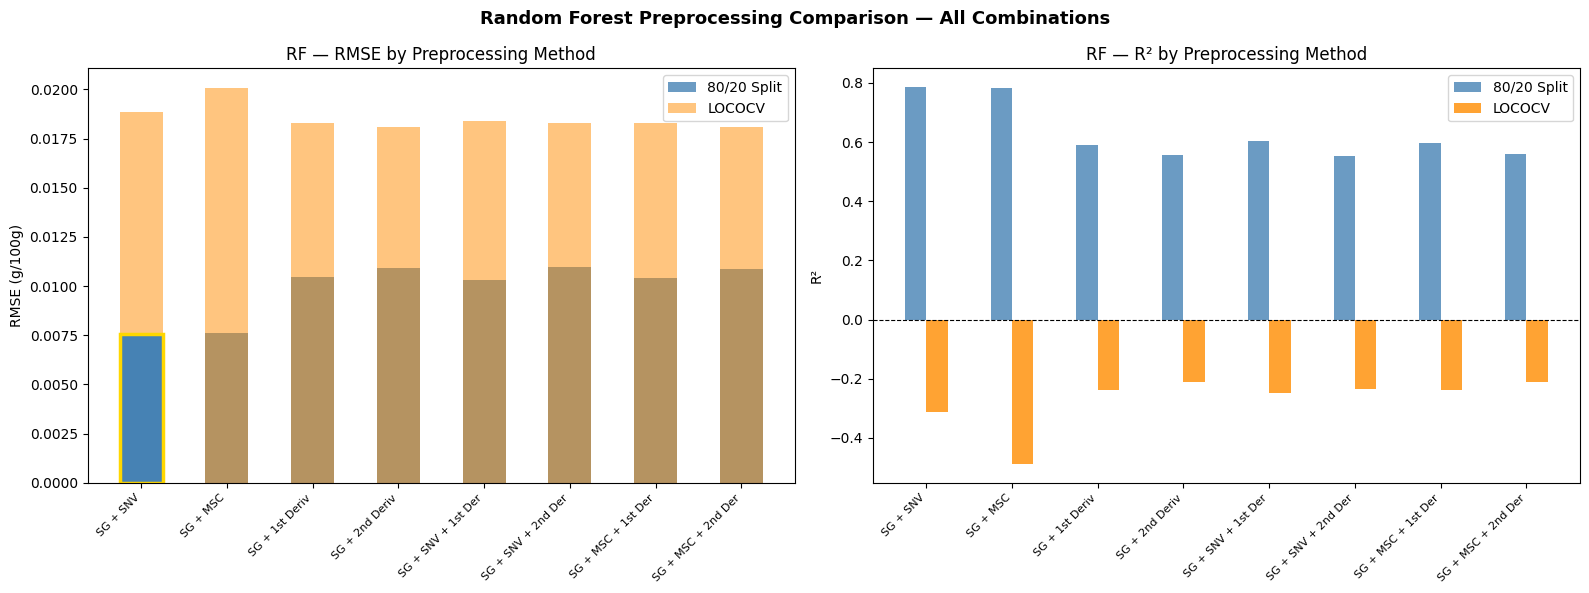

In [12]:
import pandas as pd

df_rf = pd.DataFrame(results_rf)

print("="*85)
print("              RF PREPROCESSING COMPARISON RESULTS")
print("="*85)
print(f"{'Preprocessing':<22} {'RMSE_8020':>10} {'R2_8020':>8} {'RPD_8020':>9} {'RMSE_LOCO':>10} {'R2_LOCO':>9} {'RPD_LOCO':>9}")
print("-"*85)
for _, row in df_rf.iterrows():
    print(f"{row['Preprocessing']:<22} "
          f"{row['RMSE_8020']:>10.4f} {row['R2_8020']:>8.4f} {row['RPD_8020']:>9.4f} "
          f"{row['RMSE_LOCO']:>10.4f} {row['R2_LOCO']:>9.4f} {row['RPD_LOCO']:>9.4f}")
print("="*85)

best_8020_rf = df_rf.loc[df_rf['RMSE_8020'].idxmin(), 'Preprocessing']
best_loco_rf  = df_rf.loc[df_rf['RMSE_LOCO'].idxmin(), 'Preprocessing']
print(f"\nBest 80/20 preprocessing: {best_8020_rf}")
print(f"Best LOCO  preprocessing: {best_loco_rf}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = df_rf['Preprocessing'].tolist()
x = np.arange(len(labels))
width = 0.5

ax1 = axes[0]
ax1.bar(x, df_rf['RMSE_8020'], width,
        color='steelblue', alpha=0.8, label='80/20 Split')
ax1.bar(x, df_rf['RMSE_LOCO'], width,
        color='darkorange', alpha=0.5, label='LOCOCV')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel("RMSE (g/100g)")
ax1.set_title("RF — RMSE by Preprocessing Method")
ax1.legend()
ax1.bar(df_rf['RMSE_8020'].idxmin(), df_rf['RMSE_8020'].min(),
        width, color='steelblue', alpha=1.0,
        edgecolor='gold', linewidth=2.5)

ax2 = axes[1]
ax2.bar(x - width/4, df_rf['R2_8020'], width/2,
        color='steelblue', alpha=0.8, label='80/20 Split')
ax2.bar(x + width/4, df_rf['R2_LOCO'], width/2,
        color='darkorange', alpha=0.8, label='LOCOCV')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel("R²")
ax2.set_title("RF — R² by Preprocessing Method")
ax2.legend()

plt.suptitle("Random Forest Preprocessing Comparison — All Combinations",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("RF_preprocessing_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

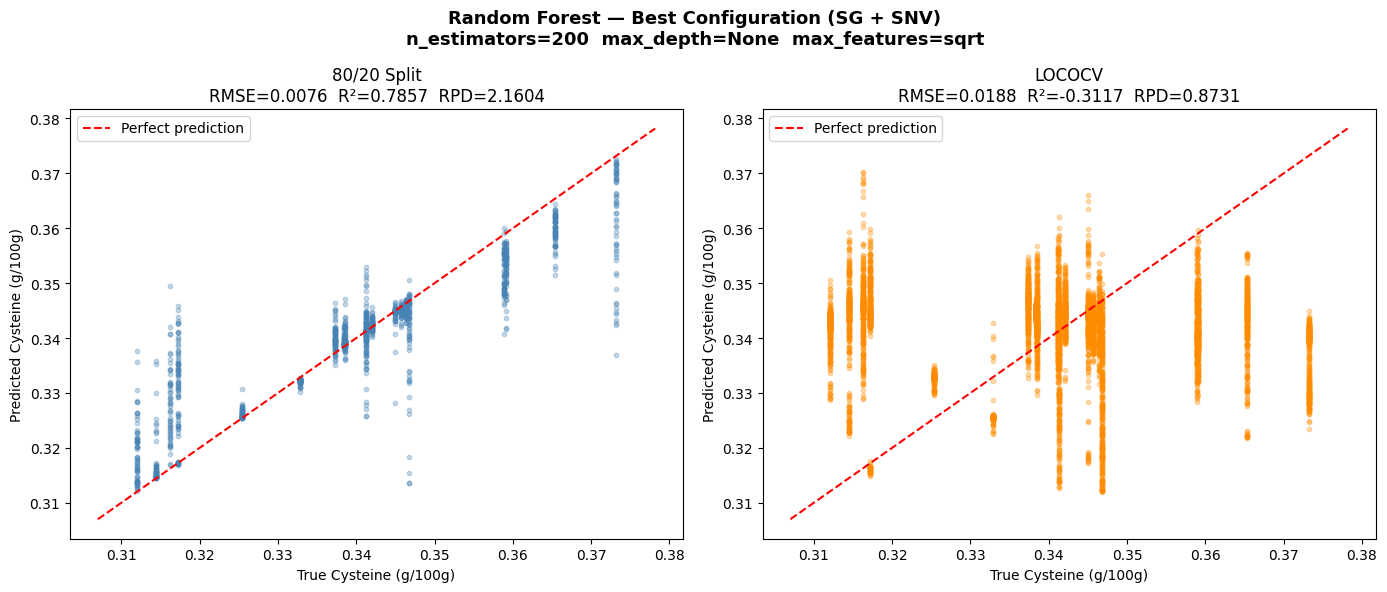


       RANDOM FOREST FINAL RESULTS SUMMARY
Metric                   80/20 Split          LOCOCV
-------------------------------------------------------
RMSE                          0.0076          0.0188
R²                            0.7857         -0.3117
RPD                           2.1604          0.8731
Preprocessing               SG + SNV        SG + SNV
n_estimators                     200             200
max_depth                       None            None
max_features                    sqrt            sqrt


In [13]:
X_best_rf = snv(savitzky_golay_smooth(X))

# 80/20 Split
X_train_rf2, X_test_rf2, y_train_rf2, y_test_rf2 = train_test_split(
    X_best_rf, y, test_size=0.2, random_state=42
)

rf_best = RandomForestRegressor(
    n_estimators=best_params_rf['n_estimators'],
    max_depth=best_params_rf['max_depth'],
    min_samples_split=best_params_rf['min_samples_split'],
    min_samples_leaf=best_params_rf['min_samples_leaf'],
    max_features=best_params_rf['max_features'],
    random_state=42,
    n_jobs=-1
)
rf_best.fit(X_train_rf2, y_train_rf2)

y_pred_train_rf = rf_best.predict(X_train_rf2)
y_pred_test_rf  = rf_best.predict(X_test_rf2)

rmse_train_rf = np.sqrt(mean_squared_error(y_train_rf2, y_pred_train_rf))
rmse_test_rf  = np.sqrt(mean_squared_error(y_test_rf2,  y_pred_test_rf))
r2_train_rf   = r2_score(y_train_rf2, y_pred_train_rf)
r2_test_rf    = r2_score(y_test_rf2,  y_pred_test_rf)
rpd_test_rf   = y_test_rf2.std() / rmse_test_rf

# LOCOCV with SG + SNV
all_y_true_rf = []
all_y_pred_rf = []

for held_out in cultivar_names:
    X_tr_l, y_tr_l = [], []
    X_te_l, y_te_l = [], []

    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        for rs, intens in spectra:
            arr     = np.array([intens])
            arr_pre = snv(savitzky_golay_smooth(arr))[0]
            if folder_name == held_out:
                X_te_l.append(arr_pre)
                y_te_l.append(meta['cys'])
            else:
                X_tr_l.append(arr_pre)
                y_tr_l.append(meta['cys'])

    rf_loco2 = RandomForestRegressor(
        n_estimators=best_params_rf['n_estimators'],
        max_depth=best_params_rf['max_depth'],
        min_samples_split=best_params_rf['min_samples_split'],
        min_samples_leaf=best_params_rf['min_samples_leaf'],
        max_features=best_params_rf['max_features'],
        random_state=42,
        n_jobs=-1
    )
    rf_loco2.fit(np.array(X_tr_l), np.array(y_tr_l))
    y_pred_l = rf_loco2.predict(np.array(X_te_l))

    all_y_true_rf.extend(y_te_l)
    all_y_pred_rf.extend(y_pred_l)

all_y_true_rf = np.array(all_y_true_rf)
all_y_pred_rf = np.array(all_y_pred_rf)

rmse_loco_rf = np.sqrt(mean_squared_error(all_y_true_rf, all_y_pred_rf))
r2_loco_rf   = r2_score(all_y_true_rf, all_y_pred_rf)
rpd_loco_rf  = all_y_true_rf.std() / rmse_loco_rf

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.scatter(y_test_rf2, y_pred_test_rf, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test_rf2.min(), y_pred_test_rf.min()) - 0.005
max_val = max(y_test_rf2.max(), y_pred_test_rf.max()) + 0.005
ax1.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel("True Cysteine (g/100g)")
ax1.set_ylabel("Predicted Cysteine (g/100g)")
ax1.set_title(f"80/20 Split\n"
              f"RMSE={rmse_test_rf:.4f}  R²={r2_test_rf:.4f}  RPD={rpd_test_rf:.4f}")
ax1.legend()

ax2 = axes[1]
ax2.scatter(all_y_true_rf, all_y_pred_rf,
            alpha=0.3, s=10, color='darkorange')
min_val = min(all_y_true_rf.min(), all_y_pred_rf.min()) - 0.005
max_val = max(all_y_true_rf.max(), all_y_pred_rf.max()) + 0.005
ax2.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5, label='Perfect prediction')
ax2.set_xlabel("True Cysteine (g/100g)")
ax2.set_ylabel("Predicted Cysteine (g/100g)")
ax2.set_title(f"LOCOCV\n"
              f"RMSE={rmse_loco_rf:.4f}  R²={r2_loco_rf:.4f}  RPD={rpd_loco_rf:.4f}")
ax2.legend()

plt.suptitle("Random Forest — Best Configuration (SG + SNV)\n"
             f"n_estimators={best_params_rf['n_estimators']}  "
             f"max_depth={best_params_rf['max_depth']}  "
             f"max_features={best_params_rf['max_features']}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("RF_final_results.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ──
print("\n" + "="*55)
print("       RANDOM FOREST FINAL RESULTS SUMMARY")
print("="*55)
print(f"{'Metric':<20} {'80/20 Split':>15} {'LOCOCV':>15}")
print("-"*55)
print(f"{'RMSE':<20} {rmse_test_rf:>15.4f} {rmse_loco_rf:>15.4f}")
print(f"{'R²':<20} {r2_test_rf:>15.4f} {r2_loco_rf:>15.4f}")
print(f"{'RPD':<20} {rpd_test_rf:>15.4f} {rpd_loco_rf:>15.4f}")
print(f"{'Preprocessing':<20} {'SG + SNV':>15} {'SG + SNV':>15}")
print(f"{'n_estimators':<20} {best_params_rf['n_estimators']:>15} {best_params_rf['n_estimators']:>15}")
print(f"{'max_depth':<20} {'None':>15} {'None':>15}")
print(f"{'max_features':<20} {best_params_rf['max_features']:>15} {best_params_rf['max_features']:>15}")
print("="*55)